# 2D

CORE SIM+ Lite — 2D Two-Group Diffusion
  Grid : 60 × 60 = 3600 nodes   (7200 DOF)
  Mesh : dx=3.39 cm,  dy=3.39 cm

[1] Building system matrices ...
  A : (7200, 7200)  nnz = 37956

[2] Static forward k-eigenvalue solve ...
  Converged in 110 iterations  |  k_eff = 0.98518992

[3] Adjoint k-eigenvalue solve ...
  Converged in 110 iterations  |  k_eff = 0.98518992

[4] Neutron noise solve ...
  Source node: (29, 29)  →  x = 98.3 cm,  y = 98.3 cm
   f =   0.1 Hz  |  |dP/P| = 2.2071e-03  |  phase = -7.6 deg
   f =   1.0 Hz  |  |dP/P| = 2.1867e-03  |  phase = -3.6 deg
   f =   5.0 Hz  |  |dP/P| = 2.1217e-03  |  phase = -14.4 deg
   f =  10.0 Hz  |  |dP/P| = 1.9512e-03  |  phase = -27.0 deg
   f =  20.0 Hz  |  |dP/P| = 1.5344e-03  |  phase = -45.5 deg

[5] Plotting ...


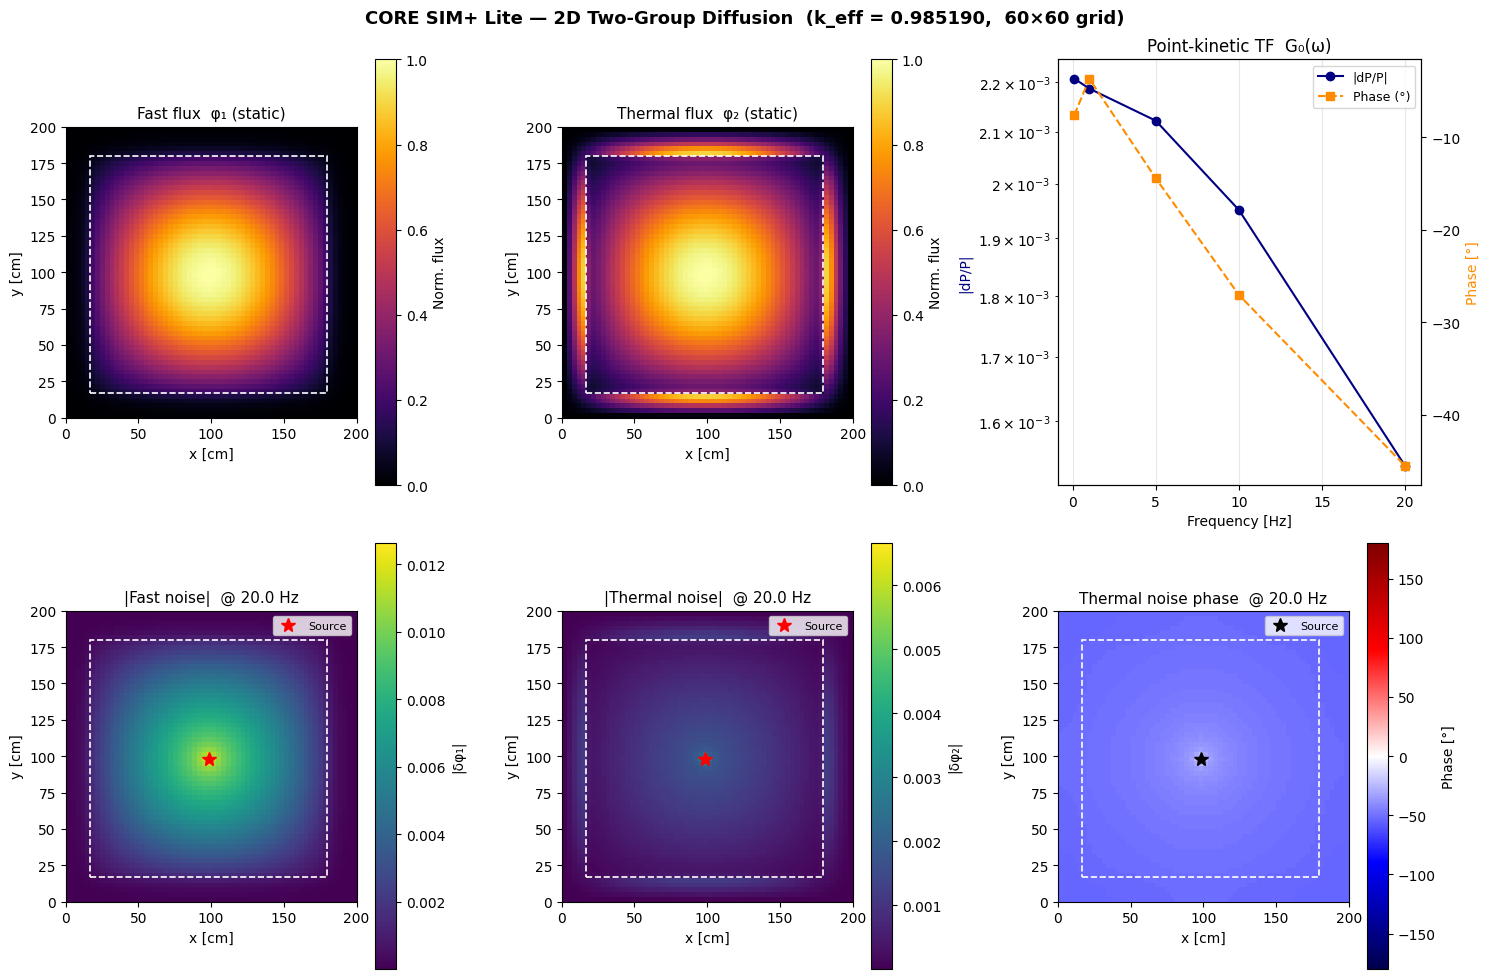

In [1]:
# -*- coding: utf-8 -*-
"""
CORE SIM+ Lite — 2D Two-Group Neutron Diffusion Solver
=======================================================
Solves:
  1. Static k-eigenvalue problem  A Φ = (1/k) F Φ   (forward + adjoint)
  2. Frequency-domain neutron noise  A_noise(ω) δΦ = S(ω)
  3. Point-kinetic transfer function extraction

Geometry:
  Square domain 200 × 200 cm
  Layout: water reflector (20 cm border) around a UO2 fuel core (160 × 160 cm)

Reference:
  Mylonakis, Vinai, Demazière — Annals of Nuclear Energy 155 (2021) 108149

"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

# ============================================================
# GEOMETRY
# ============================================================
# 2-D Cartesian domain: x in [0, Lx],  y in [0, Ly]
#
# Fuel core:  x in [ref, Lx-ref],  y in [ref, Ly-ref]
# Reflector:  the surrounding 20 cm border

Lx, Ly = 200.0, 200.0   # domain size [cm]
Nx, Ny = 60, 60          # nodes in x and y  (kept moderate for speed)
ref    = 20.0            # reflector thickness [cm]

dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

xs = np.linspace(0, Lx, Nx)
ys = np.linspace(0, Ly, Ny)

N      = Nx * Ny          # total spatial nodes
n_tot  = 2 * N            # fast + thermal

# Fuel region index bounds
fuel_ix_lo = int(ref / dx)
fuel_ix_hi = int((Lx - ref) / dx)
fuel_iy_lo = int(ref / dy)
fuel_iy_hi = int((Ly - ref) / dy)

# ============================================================
# MATERIAL MODEL  (fuel / water reflector)
# ============================================================
# Two-group cross-sections — IAEA 2-D PWR benchmark values
# Units: D [cm],  cross-sections [cm^-1]
# k_inf(fuel) ≈ 1.02; with leakage k_eff ≈ 1.00 for 160 cm active core.

def get_material(i, j):
    """Return material dict for node (i,j),  i=x-index, j=y-index."""
    in_fuel = (fuel_ix_lo <= i <= fuel_ix_hi and
               fuel_iy_lo <= j <= fuel_iy_hi)
    if in_fuel:
        return dict(D1=1.44,    D2=0.37,
                    Sa1=0.006,  Sa2=0.096,
                    S12=0.016,
                    nuf1=0.0,   nuf2=0.135)
    else:
        return dict(D1=1.50,    D2=0.20,
                    Sa1=0.0003, Sa2=0.020,
                    S12=0.040,
                    nuf1=0.0,   nuf2=0.0)

# ============================================================
# INDEX HELPERS
# ============================================================

def node(i, j):
    """Flat spatial index for (i, j)  — row-major (j varies slowly)."""
    return j * Nx + i

def fast_idx(i, j):
    """Index in the full 2N system for fast group at (i,j)."""
    return node(i, j)

def therm_idx(i, j):
    """Index in the full 2N system for thermal group at (i,j)."""
    return N + node(i, j)

# ============================================================
# BUILD SYSTEM MATRICES
# ============================================================
# Interior nodes — 5-point finite-difference Laplacian:
#
#   -D/dx² φ(i-1,j) - D/dx² φ(i+1,j)
#   -D/dy² φ(i,j-1) - D/dy² φ(i,j+1)
#   + [2D/dx² + 2D/dy² + Σ_a + Σ_r] φ(i,j)  =  source
#
# Boundary nodes — Marshak (vacuum) Robin condition per face:
#
#   0.25·φ_b + 0.5·D·(dφ/dn)_b = 0
#
# Discretised with a one-sided difference. For the left edge (i=0):
#   (0.25 + 0.5·D/dx)·φ(0,j)  -  (0.5·D/dx)·φ(1,j)  =  0
# Top/bottom edges are analogous; corner nodes combine two face
# equations into a single row by summing both face contributions.
#
# Matches McClarren Ch.18–20 BC form [A=0.25, B=0.5·D, C=0].
# Boundary rows carry no Sa, S12, or fission — pure flux condition.

def build_system():
    """Build sparse loss matrix A and fission matrix F."""

    A    = lil_matrix((n_tot, n_tot))
    Fmat = lil_matrix((n_tot, n_tot))

    cx = 1.0 / dx**2
    cy = 1.0 / dy**2

    for j in range(Ny):
        for i in range(Nx):

            m    = get_material(i, j)
            D1   = m["D1"];   D2   = m["D2"]
            Sa1  = m["Sa1"];  Sa2  = m["Sa2"]
            S12  = m["S12"]
            nuf1 = m["nuf1"]; nuf2 = m["nuf2"]

            fi = fast_idx(i, j)
            ti = therm_idx(i, j)

            # Determine which faces are on the boundary
            on_left   = (i == 0)
            on_right  = (i == Nx - 1)
            on_bottom = (j == 0)
            on_top    = (j == Ny - 1)
            on_bnd    = on_left or on_right or on_bottom or on_top

            # ── BOUNDARY NODES ───────────────────────────────────────
            # Marshak Robin condition:  0.25·φ + 0.5·D·(dφ/dn) = 0
            # Each boundary face contributes independently to the row.
            # Corner nodes sit on two faces; both contributions are summed.
            # Boundary rows carry no physics (no Sa, S12, fission) —
            # identical in structure to McClarren [A=0.25, B=0.5·D, C=0].
            if on_bnd:
                # ── fast group ──────────────────────────────────────
                diag1 = 0.0
                if on_left:
                    diag1 += 0.25 + 0.5 * D1 / dx
                    A[fi, fast_idx(i+1, j)] = -0.5 * D1 / dx
                if on_right:
                    diag1 += 0.25 + 0.5 * D1 / dx
                    A[fi, fast_idx(i-1, j)] = -0.5 * D1 / dx
                if on_bottom:
                    diag1 += 0.25 + 0.5 * D1 / dy
                    A[fi, fast_idx(i, j+1)] = -0.5 * D1 / dy
                if on_top:
                    diag1 += 0.25 + 0.5 * D1 / dy
                    A[fi, fast_idx(i, j-1)] = -0.5 * D1 / dy
                A[fi, fi] = diag1

                # ── thermal group ───────────────────────────────────
                diag2 = 0.0
                if on_left:
                    diag2 += 0.25 + 0.5 * D2 / dx
                    A[ti, therm_idx(i+1, j)] = -0.5 * D2 / dx
                if on_right:
                    diag2 += 0.25 + 0.5 * D2 / dx
                    A[ti, therm_idx(i-1, j)] = -0.5 * D2 / dx
                if on_bottom:
                    diag2 += 0.25 + 0.5 * D2 / dy
                    A[ti, therm_idx(i, j+1)] = -0.5 * D2 / dy
                if on_top:
                    diag2 += 0.25 + 0.5 * D2 / dy
                    A[ti, therm_idx(i, j-1)] = -0.5 * D2 / dy
                A[ti, ti] = diag2

                # No scattering, absorption, or fission on boundary rows
                continue

            # ── INTERIOR NODES ───────────────────────────────────────

            # ── fast group ──────────────────────────────────────────
            A[fi, fast_idx(i-1, j)] = -D1 * cx
            A[fi, fast_idx(i+1, j)] = -D1 * cx
            A[fi, fast_idx(i, j-1)] = -D1 * cy
            A[fi, fast_idx(i, j+1)] = -D1 * cy
            A[fi, fi]               =  2*D1*cx + 2*D1*cy + Sa1 + S12

            # ── thermal group ────────────────────────────────────────
            A[ti, therm_idx(i-1, j)] = -D2 * cx
            A[ti, therm_idx(i+1, j)] = -D2 * cx
            A[ti, therm_idx(i, j-1)] = -D2 * cy
            A[ti, therm_idx(i, j+1)] = -D2 * cy
            A[ti, ti]                =  2*D2*cx + 2*D2*cy + Sa2

            # Scattering: fast → thermal
            A[ti, fi] = -S12

            # ── FISSION MATRIX ───────────────────────────────────────
            Fmat[fi, fi] += nuf1
            Fmat[fi, ti] += nuf2

    return csr_matrix(A), csr_matrix(Fmat)


# ============================================================
# POWER ITERATION  (forward or adjoint)
# ============================================================

def power_iteration(A, F, n_dof, adjoint=False, tol=1e-9, max_iter=500):
    """
    Solve  A Φ = (1/k) F Φ  by power iteration.

    Standard formulation:
        phi_new = A^{-1} [ (1/k) F phi ]
        k_new   = k * sum(F phi_new) / sum(F phi)

    Parameters
    ----------
    n_dof : int  — total degrees of freedom (= n_tot = 2*N)

    Returns
    -------
    phi : ndarray  shape (n_dof,)
    k   : float
    """
    if adjoint:
        A = A.T.tocsr()
        F = F.T.tocsr()

    phi = np.ones(n_dof)
    phi /= np.linalg.norm(phi)
    k   = 1.0

    for it in range(max_iter):
        Fphi    = F @ phi
        rhs     = Fphi / k                  # (1/k) F phi
        phi_new = spsolve(A, rhs)

        Fphi_new = F @ phi_new
        k_new    = k * np.sum(Fphi_new) / np.sum(Fphi)

        phi_new /= np.linalg.norm(phi_new)

        err = abs(k_new - k) / abs(k_new)
        k   = k_new
        phi = phi_new

        if err < tol:
            print(f"  Converged in {it+1} iterations  |  k_eff = {k:.8f}")
            break
    else:
        print(f"  Warning: did not converge ({max_iter} iters)  k = {k:.6f}")

    return phi, k


# ============================================================
# DYNAMIC (NOISE) MATRIX  A_noise(ω)
# ============================================================
# From Appendix A of the paper. Starting from the static A,
# we add node-by-node:
#
#   diagonal[fast]    += iω/v1  -  νΣf1 · delay_factor
#   off-diag[fast,th] -= νΣf2  · delay_factor
#   diagonal[thermal] += iω/v2
#
# where  delay_factor = (1 - iωβ/(iω+λ)) / k_eff

def build_noise_matrix(A_static, k_eff, omega,
                       beta=0.0065, lam=0.08,
                       v1=1.0e7,    v2=2.2e5):
    """
    Build the complex-valued noise operator A_noise(ω).

    Parameters
    ----------
    A_static : real CSR matrix  (n_tot × n_tot)
    k_eff    : float
    omega    : float  angular frequency [rad/s]
    beta     : float  delayed neutron fraction
    lam      : float  precursor decay constant [1/s]
    v1, v2   : float  neutron speeds [cm/s]

    Returns
    -------
    A_noise : complex CSR matrix  (n_tot × n_tot)
    """
    A_noise = A_static.astype(complex).tolil()

    delay = (1.0 - 1j * omega * beta / (1j * omega + lam)) / k_eff

    for j in range(Ny):
        for i in range(Nx):
            m    = get_material(i, j)
            nuf1 = m["nuf1"]
            nuf2 = m["nuf2"]

            fi = fast_idx(i, j)
            ti = therm_idx(i, j)

            # Speed terms
            A_noise[fi, fi] += 1j * omega / v1
            A_noise[ti, ti] += 1j * omega / v2

            # Fission correction (A_static has no fission; add it here
            # with the frequency-dependent delayed-neutron factor)
            A_noise[fi, fi] -= nuf1 * delay
            A_noise[fi, ti] -= nuf2 * delay

    return csr_matrix(A_noise)


# ============================================================
# NOISE SOURCE  (localised absorber fluctuation)
# ============================================================

def make_absorber_source(phi_flat, noise_i, noise_j, group,
                         delta_Sigma=1e-3):
    """
    S_g(r,ω) = δΣ_a,g · φ_g^0(r)  at node (noise_i, noise_j).

    Parameters
    ----------
    phi_flat  : (n_tot,) static flux vector
    noise_i/j : x/y indices of the source node
    group     : 1 (fast) or 2 (thermal)
    """
    S = np.zeros(n_tot, dtype=complex)

    if group == 1:
        idx = fast_idx(noise_i, noise_j)
        S[idx] = delta_Sigma * phi_flat[idx]
    elif group == 2:
        idx = therm_idx(noise_i, noise_j)
        S[idx] = delta_Sigma * phi_flat[idx]

    return S


# ============================================================
# POINT-KINETIC TRANSFER FUNCTION
# ============================================================
# Eq. (17) of the paper — integrated over all spatial nodes.

def point_kinetic(phi_adj, delta_phi, phi0, v1=1.0e7, v2=2.2e5):
    """
    dP(ω)/P₀ = ∫[(1/v1)φ†_1 δφ_1 + (1/v2)φ†_2 δφ_2] dr
               ──────────────────────────────────────────
               ∫[(1/v1)φ†_1 φ_1  + (1/v2)φ†_2 φ_2 ] dr

    All arrays are flat (n_tot,).
    """
    phi_adj_1 = phi_adj[:N];    phi_adj_2 = phi_adj[N:]
    delta_1   = delta_phi[:N];  delta_2   = delta_phi[N:]
    phi0_1    = phi0[:N];       phi0_2    = phi0[N:]

    num = np.sum(phi_adj_1 * delta_1 / v1) + np.sum(phi_adj_2 * delta_2 / v2)
    den = np.sum(phi_adj_1 * phi0_1  / v1) + np.sum(phi_adj_2 * phi0_2  / v2)
    return num / den


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    print("=" * 60)
    print("CORE SIM+ Lite — 2D Two-Group Diffusion")
    print(f"  Grid : {Nx} × {Ny} = {N} nodes   ({Nx*Ny*2} DOF)")
    print(f"  Mesh : dx={dx:.2f} cm,  dy={dy:.2f} cm")
    print("=" * 60)

    # ── [1] Build matrices ───────────────────────────────────────
    print("\n[1] Building system matrices ...")
    A, F = build_system()
    print(f"  A : {A.shape}  nnz = {A.nnz}")

    # ── [2] Static forward solve ─────────────────────────────────
    print("\n[2] Static forward k-eigenvalue solve ...")
    phi, k_eff = power_iteration(A, F, n_tot)

    phi_fast_flat  = phi[:N].copy()
    phi_therm_flat = phi[N:].copy()

    # 2-D reshapes for plotting (shape: Ny × Nx)
    phi_fast_2d  = phi_fast_flat.reshape(Ny, Nx)
    phi_therm_2d = phi_therm_flat.reshape(Ny, Nx)

    # Normalise to peak = 1
    phi_fast_2d  /= np.max(phi_fast_2d)
    phi_therm_2d /= np.max(phi_therm_2d)
    phi_fast_flat  = phi_fast_2d.ravel()
    phi_therm_flat = phi_therm_2d.ravel()
    phi[:N]  = phi_fast_flat
    phi[N:]  = phi_therm_flat

    # ── [3] Adjoint solve ────────────────────────────────────────
    print("\n[3] Adjoint k-eigenvalue solve ...")
    phi_adj, k_adj = power_iteration(A, F, n_tot, adjoint=True)

    # Normalise adjoint so that <φ†, φ> = 1
    norm_adj = (np.sum(phi_adj[:N] * phi_fast_flat) +
                np.sum(phi_adj[N:] * phi_therm_flat))
    phi_adj /= norm_adj

    phi_adj_fast_2d  = phi_adj[:N].reshape(Ny, Nx)
    phi_adj_therm_2d = phi_adj[N:].reshape(Ny, Nx)

    # ── [4] Frequency-domain noise solve ─────────────────────────
    print("\n[4] Neutron noise solve ...")

    # Source: thermal absorber at the centre of the fuel region
    src_i = (fuel_ix_lo + fuel_ix_hi) // 2
    src_j = (fuel_iy_lo + fuel_iy_hi) // 2
    print(f"  Source node: ({src_i}, {src_j})  →  "
          f"x = {xs[src_i]:.1f} cm,  y = {ys[src_j]:.1f} cm")

    frequencies = [0.1, 1.0, 5.0, 10.0, 20.0]
    dP_list     = []

    for f_hz in frequencies:
        omega   = 2 * np.pi * f_hz
        A_noise = build_noise_matrix(A, k_eff, omega)
        S       = make_absorber_source(phi, src_i, src_j, group=2)
        dphi    = spsolve(A_noise, S)

        dP = point_kinetic(phi_adj, dphi, phi)
        dP_list.append(dP)
        print(f"   f = {f_hz:5.1f} Hz  |  |dP/P| = {abs(dP):.4e}"
              f"  |  phase = {np.angle(dP, deg=True):.1f} deg")

    # Save noise maps at the highest frequency for plotting
    f_plot  = frequencies[-1]
    omega_p = 2 * np.pi * f_plot
    A_np    = build_noise_matrix(A, k_eff, omega_p)
    S_p     = make_absorber_source(phi, src_i, src_j, group=2)
    dphi_p  = spsolve(A_np, S_p)

    noise_fast_2d  = np.abs(dphi_p[:N]).reshape(Ny, Nx)
    noise_therm_2d = np.abs(dphi_p[N:]).reshape(Ny, Nx)
    phase_fast_2d  = np.angle(dphi_p[:N], deg=True).reshape(Ny, Nx)
    phase_therm_2d = np.angle(dphi_p[N:], deg=True).reshape(Ny, Nx)

    # ── [5] Visualisation ─────────────────────────────────────────
    print("\n[5] Plotting ...")

    extent = [0, Lx, 0, Ly]
    fuel_rect = plt.Rectangle(
        (xs[fuel_ix_lo], ys[fuel_iy_lo]),
        xs[fuel_ix_hi] - xs[fuel_ix_lo],
        ys[fuel_iy_hi] - ys[fuel_iy_lo],
        linewidth=1.2, edgecolor="white", facecolor="none", linestyle="--"
    )

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(
        f"CORE SIM+ Lite — 2D Two-Group Diffusion  "
        f"(k_eff = {k_eff:.6f},  {Nx}×{Ny} grid)",
        fontsize=13, fontweight="bold"
    )

    def add_fuel_border(ax):
        """Draw dashed white rectangle marking the fuel-reflector interface."""
        r = plt.Rectangle(
            (xs[fuel_ix_lo], ys[fuel_iy_lo]),
            xs[fuel_ix_hi] - xs[fuel_ix_lo],
            ys[fuel_iy_hi] - ys[fuel_iy_lo],
            linewidth=1.2, edgecolor="white",
            facecolor="none", linestyle="--"
        )
        ax.add_patch(r)

    def fmt_ax(ax, title, xlabel="x [cm]", ylabel="y [cm]"):
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_xlim(0, Lx);   ax.set_ylim(0, Ly)

    # --- (0,0)  Fast static flux ------------------------------------
    ax = axes[0, 0]
    im = ax.imshow(phi_fast_2d, origin="lower", extent=extent,
                   cmap="inferno", vmin=0)
    plt.colorbar(im, ax=ax, label="Norm. flux")
    add_fuel_border(ax)
    fmt_ax(ax, "Fast flux  φ₁ (static)")

    # --- (0,1)  Thermal static flux ---------------------------------
    ax = axes[0, 1]
    im = ax.imshow(phi_therm_2d, origin="lower", extent=extent,
                   cmap="inferno", vmin=0)
    plt.colorbar(im, ax=ax, label="Norm. flux")
    add_fuel_border(ax)
    fmt_ax(ax, "Thermal flux  φ₂ (static)")

    # --- (0,2)  Point-kinetic transfer function ----------------------
    ax   = axes[0, 2]
    ax2  = ax.twinx()
    freqs = np.array(frequencies)
    amps  = np.abs(dP_list)
    phs   = np.angle(dP_list, deg=True)
    l1, = ax.semilogy(freqs, amps,  "o-",  color="navy",       label="|dP/P|")
    l2, = ax2.plot(   freqs, phs,   "s--", color="darkorange",  label="Phase (°)")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("|dP/P|",    color="navy")
    ax2.set_ylabel("Phase [°]", color="darkorange")
    ax.set_title("Point-kinetic TF  G₀(ω)")
    ax.legend(handles=[l1, l2], loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- (1,0)  Fast noise amplitude --------------------------------
    ax = axes[1, 0]
    im = ax.imshow(noise_fast_2d, origin="lower", extent=extent,
                   cmap="viridis")
    plt.colorbar(im, ax=ax, label="|δφ₁|")
    ax.plot(xs[src_i], ys[src_j], "r*", ms=10, label="Source")
    add_fuel_border(ax)
    fmt_ax(ax, f"|Fast noise|  @ {f_plot} Hz")
    ax.legend(fontsize=8)

    # --- (1,1)  Thermal noise amplitude -----------------------------
    ax = axes[1, 1]
    im = ax.imshow(noise_therm_2d, origin="lower", extent=extent,
                   cmap="viridis")
    plt.colorbar(im, ax=ax, label="|δφ₂|")
    ax.plot(xs[src_i], ys[src_j], "r*", ms=10, label="Source")
    add_fuel_border(ax)
    fmt_ax(ax, f"|Thermal noise|  @ {f_plot} Hz")
    ax.legend(fontsize=8)

    # --- (1,2)  Thermal noise phase ---------------------------------
    ax = axes[1, 2]
    im = ax.imshow(phase_therm_2d, origin="lower", extent=extent,
                   cmap="seismic", vmin=-180, vmax=180)
    plt.colorbar(im, ax=ax, label="Phase [°]")
    ax.plot(xs[src_i], ys[src_j], "k*", ms=10, label="Source")
    add_fuel_border(ax)
    fmt_ax(ax, f"Thermal noise phase  @ {f_plot} Hz")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()